In [209]:
# Importing neccessary libraries

import pandas as  pd, numpy as np, matplotlib.pyplot as plt , seaborn as sns, yfinance as yf , warnings
warnings.simplefilter(action='ignore', category=[FutureWarning ,UserWarning])

print("Libraries imported successfully")

Libraries imported successfully


In [210]:
# Define Fetch function here

def fetch(ticker,start,end):
    """Fetching Historical Data OHLV"""
    try:
        data = yf.download(ticker,start=start,end=end,auto_adjust=True, multi_level_index=False)
        #df = df.dropna(inplace=True)
        df = pd.DataFrame(data)
        return df
    except Exception as e:
        print("Error occur :" ,e)

print("pass")

pass


In [211]:
# Clean & Validate Dataset
def clean_validate(df):
    try:
        #df.columns = df.columns.str.lower()
        # FIX: Flatten columns to single-level lowercase strings
        df.columns = df.columns.get_level_values(0).str.lower()
        cond=(
            (df['high'] >=df['open'])&
            (df['high'] >=df['low'] )&
            (df['high'] >=df['close'])&
            (df['open'] >=df['close'])&
            (df['close'] >=df['low'])&
            (df['open']>=0)&
            (df['close'] >=0)
        )
        df = df[cond].copy()
        print(f"\n Preview :\n")
        print(f"dataset shape :{df.shape}")
        print(f"Starting Data :{df.index.min()}")
        print(f"Ending Date :{df.index.max()}")
        return df
    except Exception as e:
        print("Error occur :", e)

In [212]:
# Fetch AAPL dataset
df = fetch("AAPL","2010-01-01","2025-12-31")

[*********************100%***********************]  1 of 1 completed


In [213]:
# Operation Practise
df = clean_validate(df)


 Preview :

dataset shape :(1916, 5)
Starting Data :2010-01-05 00:00:00
Ending Date :2025-12-26 00:00:00


In [214]:
# Calculating Indicators 
# we use pandas.rolling() which is highly optimize, vectorization operation

df['SMA_50'] = df['close'].rolling(window=50).mean()
df['SMA_200'] = df['close'].rolling(window=200).mean()
df.dropna(inplace=True)

print(df.head()) 

                close       high        low       open     volume     SMA_50  \
Date                                                                           
2011-08-17  11.409789  11.532152  11.336611  11.465872  442061200  10.425222   
2011-08-18  10.978223  11.176165  10.837865  11.121880  851435200  10.442023   
2011-08-19  10.677712  11.006715  10.676813  10.861858  775888400  10.452790   
2011-08-22  10.690004  10.943130  10.649517  10.932032  535315200  10.465614   
2011-08-31  11.541451  11.758886  11.452378  11.713600  522586400  10.498023   

             SMA_200  
Date                  
2011-08-17  8.743439  
2011-08-18  8.766183  
2011-08-19  8.787935  
2011-08-22  8.809808  
2011-08-31  8.836008  


In [215]:
# Step 2: Generate Trading Signals (Vectorized Logic)
def generate_signals(df):
    """Generating Buy/Sell signal vectorized."""
    
    # When SMA_50 > SMA_200 , we signal 'Buy' (1.0), otherwise 'Sell' (0.0)
    df['signal'] = 0.0 # Intitial Signal default
    df['signal'] =np.where(df['SMA_50'] > df['SMA_200'] , 1.0,0.0)
    
    # Calaculate the difference in signals to get actual 'Entry' and 'Exit' point.
    # A Change from 0 to 1 means 'Buy' (+1) , a change from 1 to 0 means sell(-1).
    
    df['position'] = df['signal'].diff()
    return df  

In [216]:
def visualize(df):
    fig = plt.figure(figsize=(12,6))
    ax1 = fig.add_subplot(111, ylabel="Price in $")

    # 1. Use the .index and .values to avoid passing complex Pandas objects to ax1
    ax1.plot(df.index, df['close'].values, color='#A0A0FF', label='Close Price')

    # 2. Plot SMA lines (ensure these columns exist and are lowercase)
    if 'SMA_50' in df.columns:
        ax1.plot(df.index, df['SMA_50'].values, label='SMA 50')
        ax1.plot(df.index, df['SMA_200'].values, label='SMA 200')

    # 3. Fix Buy/Sell signal plots
    # Filter the index and values separately
    buy_signals = df[df.position == 1.0]
    ax1.plot(buy_signals.index, buy_signals['SMA_50'].values, 
            '^', markersize=10, color='g', label='Buy')

    sell_signals = df[df.position == -1.0]
    ax1.plot(sell_signals.index, sell_signals['SMA_50'].values, 
            'v', markersize=10, color='r', label='Sell')

    plt.legend()
    plt.title("Vectorized Trading Signals")
    plt.show()
    return None

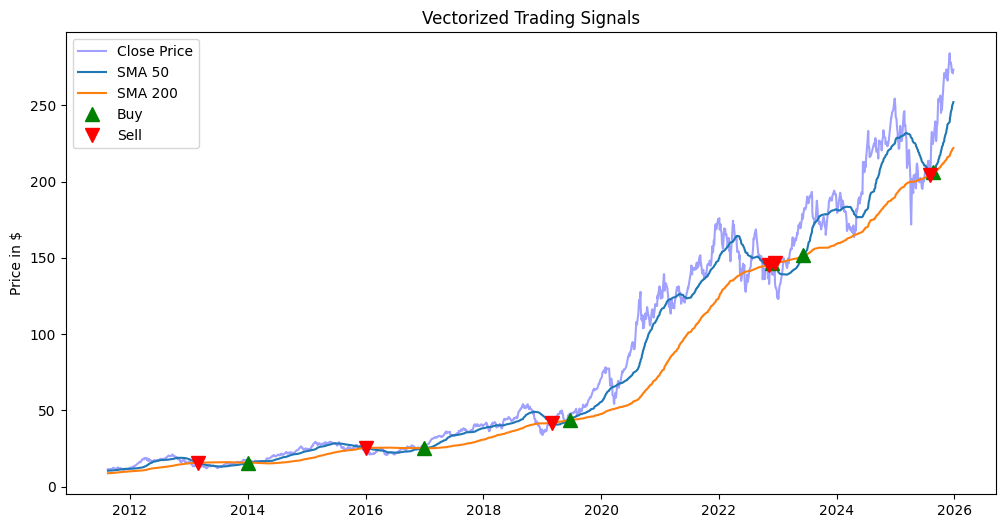

In [217]:
df = generate_signals(df)
visualize(df)

In [218]:
# Calculate Strategy Performance 

def backtest_strategy(df):
    """Calculate strategy returns using vector operations."""
    # Calculate daily percentage returns of the stock
    df['Daily_Return'] = df['close'].pct_change()
    
    # Calculate strategy returns: shift the position by one day
    # to avoid "Lookhead bias" ( acting tommorow's data today)
    df['Strategy_Return'] = df['position'].shift(1) *df['Daily_Return']
    
    # Calculating commulative returns
    df['Cumulative_Return'] = (1+df['Strategy_Return']).comprod()
    
    return df
     


In [ ]:
df = backtest_strategy(df)

# Plot cumulative return
df[['Cumulative_Return']].plot(figsize=(10,6))
plt.title("Strategy Performance vs Buy-and-hold")
plt.show()
sharpe_ratio = np.sqrt(252)*df['Strategy_Return'].mean() / df['Strategy_Return'].std()
print(f"\Annualized Shape Ratio :{sharpe_ration}")